In [1]:
# ============================================================
# PHASE 14B — FIX GENOMIC FEATURE NAME MAPPING
# ============================================================
# Goal:
# Fix handcrafted genomic feature-name mapping for Phase 14 explainability.
#
# Why:
# Phase 14 ran correctly, but feature names were generic:
# genomic_feature_0 ... genomic_feature_355
#
# Therefore all 356 features were grouped as Other_basic.
#
# This phase tries to:
# 1. Find real feature-name files from Phase 2/3.
# 2. Load feature names if available.
# 3. Reconstruct K3/K4/Basic feature names if no file is found.
# 4. Remap feature groups:
#    - Basic
#    - GC_content
#    - CpG_related
#    - Skew
#    - Nucleotide_composition
#    - K3_kmer
#    - K4_kmer
# 5. Recompute grouped permutation/SHAP importance.
# 6. Produce manuscript-ready outputs.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import itertools
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE14_DIR = PROJECT_DIR / "model" / "phase14_explainability_analysis"

PHASE14_RESULT_DIR = PHASE14_DIR / "results"
PHASE14_FIGURE_DIR = PHASE14_DIR / "figures"

PHASE14B_DIR = PROJECT_DIR / "model" / "phase14b_fix_genomic_feature_mapping"
RESULT_DIR = PHASE14B_DIR / "results"
FIGURE_DIR = PHASE14B_DIR / "figures"
EXCEL_DIR = PHASE14B_DIR / "excel"
REPORT_DIR = PHASE14B_DIR / "reports"

for d in [PHASE14B_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 14B output:", PHASE14B_DIR)

Mounted at /content/drive
Phase 14B output: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def round_numeric_columns(df, digits=6):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Missing:", path)
    return None


def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def generate_kmers(k):
    return ["".join(p) for p in itertools.product("ACGT", repeat=k)]


def normalize_feature_name(x):
    return str(x).strip()


def infer_feature_group_v2(feature_name):
    """
    More robust grouping for genomic handcrafted features.
    """
    f = str(feature_name).strip()
    fl = f.lower()

    # Explicit basic/composition
    if fl in ["a", "c", "g", "t", "freq_a", "freq_c", "freq_g", "freq_t",
              "a_content", "c_content", "g_content", "t_content"]:
        return "Nucleotide_composition"

    # GC/CpG
    if "cpg" in fl or "cg_ratio" in fl or "cpg_ratio" in fl or "observed_expected" in fl:
        return "CpG_related"

    if "gc" in fl:
        return "GC_content"

    # Skew
    if "skew" in fl:
        return "Skew"

    # Basic positional/bin features
    if "bin" in fl or "window" in fl or "positional" in fl:
        if "gc" in fl:
            return "GC_content"
        return "Other_basic"

    # K-mer with prefixes
    if fl.startswith("k3_") or fl.startswith("3mer_") or fl.startswith("kmer3_"):
        return "K3_kmer"
    if fl.startswith("k4_") or fl.startswith("4mer_") or fl.startswith("kmer4_"):
        return "K4_kmer"

    # Raw k-mer names
    fu = f.upper()
    if len(fu) == 3 and set(fu).issubset(set("ACGT")):
        return "K3_kmer"

    if len(fu) == 4 and set(fu).issubset(set("ACGT")):
        return "K4_kmer"

    # Generic reconstructed names
    if fl.startswith("k3:") or fl.startswith("k3_"):
        return "K3_kmer"
    if fl.startswith("k4:") or fl.startswith("k4_"):
        return "K4_kmer"

    return "Other_basic"


def detect_feature_name_column(df):
    """
    Find likely column containing feature names.
    """
    candidates = [
        "feature_name", "feature", "name", "column", "column_name",
        "features", "Feature", "Feature_Name", "variable", "var"
    ]

    for c in candidates:
        if c in df.columns:
            return c

    # If one-column file, use that
    if df.shape[1] == 1:
        return df.columns[0]

    # Fallback: find object column with many unique values
    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    if object_cols:
        object_cols = sorted(object_cols, key=lambda c: df[c].nunique(), reverse=True)
        return object_cols[0]

    return None


def validate_feature_names(feature_names, expected_n=356):
    feature_names = [str(x).strip() for x in feature_names]
    feature_names = [x for x in feature_names if x != "" and x.lower() != "nan"]

    ok = len(feature_names) == expected_n
    return ok, feature_names

In [3]:
# ============================================================
# SEARCH FOR EXISTING FEATURE NAME FILES
# ============================================================

search_patterns = [
    "*feature*name*.csv",
    "*feature*names*.csv",
    "*feature*name*.txt",
    "*feature*names*.txt",
    "*selected*feature*.csv",
    "*selected*features*.csv",
    "*k3*k4*.csv",
    "*k3*k4*feature*.csv",
    "*genomic*feature*.csv",
    "*genomic*features*.csv",
    "*column*.csv",
    "*columns*.csv",
    "*feature_info*.csv",
]

candidate_files = []

for pattern in search_patterns:
    files = sorted(PROJECT_DIR.rglob(pattern))
    for f in files:
        if f not in candidate_files:
            candidate_files.append(f)

print("Candidate feature-name files found:", len(candidate_files))

for i, f in enumerate(candidate_files[:100]):
    print(i, f)

Candidate feature-name files found: 15
0 /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_test_k3_k4_k5_plus_basic_v1.csv
1 /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_test_k3_k4_plus_basic_v1.csv
2 /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_train_k3_k4_k5_plus_basic_v1.csv
3 /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_train_k3_k4_plus_basic_v1.csv
4 /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_val_k3_k4_k5_plus_basic_v1.csv
5 /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_val_k3_k4_plus_basic_v1.csv
6 /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_genomic_k3k4basic_v1.csv
7 /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_genomic_

In [4]:
# ============================================================
# TRY LOADING 356 FEATURE NAMES FROM CANDIDATE FILES
# ============================================================

EXPECTED_N = 356

loaded_feature_candidates = []

for f in candidate_files:
    try:
        if f.suffix.lower() == ".csv":
            df = pd.read_csv(f)
            col = detect_feature_name_column(df)

            if col is None:
                continue

            names = df[col].astype(str).tolist()
            ok, cleaned = validate_feature_names(names, expected_n=EXPECTED_N)

            loaded_feature_candidates.append({
                "path": str(f),
                "shape": df.shape,
                "column_used": col,
                "n_cleaned_names": len(cleaned),
                "is_expected_356": ok,
                "preview": cleaned[:10]
            })

        elif f.suffix.lower() == ".txt":
            with open(f, "r") as file:
                names = [line.strip() for line in file.readlines()]

            ok, cleaned = validate_feature_names(names, expected_n=EXPECTED_N)

            loaded_feature_candidates.append({
                "path": str(f),
                "shape": "txt",
                "column_used": "line",
                "n_cleaned_names": len(cleaned),
                "is_expected_356": ok,
                "preview": cleaned[:10]
            })

    except Exception as e:
        pass

feature_candidate_summary_df = pd.DataFrame(loaded_feature_candidates)

if feature_candidate_summary_df.empty:
    print("No usable feature-name candidate loaded.")
else:
    display(feature_candidate_summary_df.sort_values(
        ["is_expected_356", "n_cleaned_names"],
        ascending=[False, False]
    ).head(30))

save_df(
    feature_candidate_summary_df,
    RESULT_DIR / "phase14b_feature_name_candidate_files.csv"
)

,path,shape,column_used,n_cleaned_names,is_expected_356,preview
1,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv,"(356, 5)",feature_name,356,True,"[genomic_feature_320, genomic_feature_223, genomic_feature_227, genomic_feature_268, genomic_feature_102, genomic_feature_183, genomic_feature_153, genomic_feature_54, genomic_feature_69, genomic_feature_270]"
2,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_handcrafted_feature_info.csv,"(356, 3)",feature_name,356,True,"[genomic_feature_0, genomic_feature_1, genomic_feature_2, genomic_feature_3, genomic_feature_4, genomic_feature_5, genomic_feature_6, genomic_feature_7, genomic_feature_8, genomic_feature_9]"
3,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_rf_shap_feature_importance.csv,"(356, 4)",feature_name,356,True,"[genomic_feature_27, genomic_feature_62, genomic_feature_86, genomic_feature_254, genomic_feature_118, genomic_feature_278, genomic_feature_69, genomic_feature_185, genomic_feature_203, genomic_feature_32]"
5,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,"(50, 4)",feature,50,False,"[k4_GTAG, k4_GGTA, k4_ACCA, k4_TCTG, k4_CTGT, k4_CCGA, k4_CCAT, k4_TGAC, k4_ATCC, k4_CGAC]"
4,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/results/phase2_1_genomic_feature_ablation_5fold_cv_v1.csv,"(20, 14)",feature_set,20,False,"[K3 + K4 + K5 + Basic, K3 + K4 + K5 + Basic, K3 + K4 + Basic, K4 + Basic, K3 + K4 + K5 + Basic, K4 + Basic, K4 + Basic, K3 + K4 + Basic, K3 + K4 + Basic, K3 + Basic]"
0,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_group_importance.csv,"(1, 6)",feature_group,1,False,[Other_basic]


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_feature_name_candidate_files.csv


In [5]:
# ============================================================
# SELECT REAL FEATURE NAMES IF AVAILABLE
# ============================================================
# If multiple valid files exist, inspect the table from Cell 4.
# This code automatically picks the first file with exactly 356 names.
# You can override SELECTED_FEATURE_FILE manually if needed.
# ============================================================

SELECTED_FEATURE_FILE = None

valid_356 = feature_candidate_summary_df[
    feature_candidate_summary_df["is_expected_356"] == True
].copy() if not feature_candidate_summary_df.empty else pd.DataFrame()

if not valid_356.empty:
    SELECTED_FEATURE_FILE = Path(valid_356.iloc[0]["path"])
    print("Auto-selected feature-name file:", SELECTED_FEATURE_FILE)
else:
    print("No exact 356 feature-name file found.")
    print("Will reconstruct feature names using K3/K4/Basic assumption.")

# Manual override example:
# SELECTED_FEATURE_FILE = Path("/content/drive/MyDrive/Project_Protein/path/to/your/feature_names.csv")

Auto-selected feature-name file: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv


In [6]:
# ============================================================
# LOAD OR RECONSTRUCT FEATURE NAMES
# ============================================================
# Expected handcrafted genomic features = 356.
#
# Known design:
# K3 = 64 features
# K4 = 256 features
# Total K3 + K4 = 320
# Basic = 36 features
# Total = 356
#
# The exact order may be:
# [basic 36] + [K3 64] + [K4 256]
# OR [K3 64] + [K4 256] + [basic 36]
#
# From earlier Phase 2 memory: K3+K4+Basic selected = 356.
# Need to align with how array was created.
#
# If no feature-name file is found, this code creates both possible
# reconstructed orders and lets you choose.
# ============================================================

def load_feature_names_from_file(path):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        col = detect_feature_name_column(df)
        assert col is not None, f"Cannot find feature name column in {path}"
        names = df[col].astype(str).tolist()
    else:
        with open(path, "r") as f:
            names = [line.strip() for line in f.readlines()]

    ok, cleaned = validate_feature_names(names, expected_n=EXPECTED_N)
    assert ok, f"Feature file does not contain exactly {EXPECTED_N} names: {len(cleaned)}"

    return cleaned


# Define basic feature names if reconstruction is needed
basic_36_names = [
    "seq_length",
    "A_content",
    "C_content",
    "G_content",
    "T_content",
    "GC_content",
    "AT_content",
    "CpG_count",
    "CpG_ratio",
    "CpG_observed_expected",
    "GC_skew",
    "AT_skew",
]

# Add 24 positional/bin features to reach 36
# These names are generic but interpretable.
for i in range(1, 7):
    basic_36_names.extend([
        f"bin{i}_GC_content",
        f"bin{i}_CpG_ratio",
        f"bin{i}_GC_skew",
        f"bin{i}_AT_skew",
    ])

assert len(basic_36_names) == 36, len(basic_36_names)

k3_names = [f"K3_{k}" for k in generate_kmers(3)]
k4_names = [f"K4_{k}" for k in generate_kmers(4)]

assert len(k3_names) == 64
assert len(k4_names) == 256

if SELECTED_FEATURE_FILE is not None:
    genomic_feature_names = load_feature_names_from_file(SELECTED_FEATURE_FILE)
    feature_name_source = f"loaded_from_file::{SELECTED_FEATURE_FILE}"
else:
    # Default assumption: K3 + K4 + Basic, based on naming "K3/K4/Basic"
    genomic_feature_names = k3_names + k4_names + basic_36_names
    feature_name_source = "reconstructed_order::K3_64 + K4_256 + Basic_36"

assert len(genomic_feature_names) == EXPECTED_N

print("Feature name source:", feature_name_source)
print("Number of feature names:", len(genomic_feature_names))
print("First 20:", genomic_feature_names[:20])
print("Last 20:", genomic_feature_names[-20:])

Feature name source: loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
Number of feature names: 356
First 20: ['genomic_feature_320', 'genomic_feature_223', 'genomic_feature_227', 'genomic_feature_268', 'genomic_feature_102', 'genomic_feature_183', 'genomic_feature_153', 'genomic_feature_54', 'genomic_feature_69', 'genomic_feature_270', 'genomic_feature_278', 'genomic_feature_203', 'genomic_feature_110', 'genomic_feature_326', 'genomic_feature_118', 'genomic_feature_241', 'genomic_feature_228', 'genomic_feature_80', 'genomic_feature_56', 'genomic_feature_171']
Last 20: ['genomic_feature_149', 'genomic_feature_168', 'genomic_feature_318', 'genomic_feature_33', 'genomic_feature_282', 'genomic_feature_236', 'genomic_feature_108', 'genomic_feature_253', 'genomic_feature_221', 'genomic_feature_136', 'genomic_feature_32', 'genomic_feature_47', 'genomic_feature_202', 'genomic_feature

In [7]:
# ============================================================
# CREATE CORRECTED FEATURE INFO TABLE
# ============================================================

feature_info_corrected_df = pd.DataFrame({
    "feature_index": np.arange(EXPECTED_N),
    "feature_name": genomic_feature_names
})

feature_info_corrected_df["feature_group"] = feature_info_corrected_df["feature_name"].apply(infer_feature_group_v2)
feature_info_corrected_df["feature_name_source"] = feature_name_source

display(feature_info_corrected_df.head(40))
display(feature_info_corrected_df.tail(40))
display(feature_info_corrected_df["feature_group"].value_counts())

save_df(
    feature_info_corrected_df,
    RESULT_DIR / "phase14b_corrected_genomic_feature_info.csv"
)

,feature_index,feature_name,feature_group,feature_name_source
0,0,genomic_feature_320,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
1,1,genomic_feature_223,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
2,2,genomic_feature_227,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
3,3,genomic_feature_268,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
4,4,genomic_feature_102,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
5,5,genomic_feature_183,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
6,6,genomic_feature_153,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
7,7,genomic_feature_54,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
8,8,genomic_feature_69,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
9,9,genomic_feature_270,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv


,feature_index,feature_name,feature_group,feature_name_source
316,316,genomic_feature_46,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
317,317,genomic_feature_74,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
318,318,genomic_feature_213,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
319,319,genomic_feature_52,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
320,320,genomic_feature_239,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
321,321,genomic_feature_305,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
322,322,genomic_feature_119,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
323,323,genomic_feature_173,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
324,324,genomic_feature_34,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
325,325,genomic_feature_28,Other_basic,loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv


,count
feature_group,
Other_basic,356


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_genomic_feature_info.csv


In [8]:
# ============================================================
# COMPARE OLD VS CORRECTED FEATURE GROUPING
# ============================================================

old_feature_info_path = PHASE14_RESULT_DIR / "phase14_genomic_handcrafted_feature_info.csv"

old_feature_info_df = read_csv_if_exists(old_feature_info_path)

if old_feature_info_df is not None:
    comparison_df = old_feature_info_df[["feature_index", "feature_name", "feature_group"]].copy()
    comparison_df = comparison_df.rename(columns={
        "feature_name": "old_feature_name",
        "feature_group": "old_feature_group"
    })

    comparison_df = comparison_df.merge(
        feature_info_corrected_df[["feature_index", "feature_name", "feature_group"]],
        on="feature_index",
        how="left"
    )

    comparison_df = comparison_df.rename(columns={
        "feature_name": "corrected_feature_name",
        "feature_group": "corrected_feature_group"
    })

    display(comparison_df.head(30))
    display(pd.crosstab(comparison_df["old_feature_group"], comparison_df["corrected_feature_group"]))

    save_df(
        comparison_df,
        RESULT_DIR / "phase14b_old_vs_corrected_feature_mapping.csv"
    )
else:
    print("Old Phase 14 feature info not found. Skipping comparison.")

Loaded: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_handcrafted_feature_info.csv


,feature_index,old_feature_name,old_feature_group,corrected_feature_name,corrected_feature_group
0,0,genomic_feature_0,Other_basic,genomic_feature_320,Other_basic
1,1,genomic_feature_1,Other_basic,genomic_feature_223,Other_basic
2,2,genomic_feature_2,Other_basic,genomic_feature_227,Other_basic
3,3,genomic_feature_3,Other_basic,genomic_feature_268,Other_basic
4,4,genomic_feature_4,Other_basic,genomic_feature_102,Other_basic
5,5,genomic_feature_5,Other_basic,genomic_feature_183,Other_basic
6,6,genomic_feature_6,Other_basic,genomic_feature_153,Other_basic
7,7,genomic_feature_7,Other_basic,genomic_feature_54,Other_basic
8,8,genomic_feature_8,Other_basic,genomic_feature_69,Other_basic
9,9,genomic_feature_9,Other_basic,genomic_feature_270,Other_basic


corrected_feature_group,Other_basic
old_feature_group,
Other_basic,356


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_old_vs_corrected_feature_mapping.csv


In [9]:
# ============================================================
# LOAD PHASE 14 FEATURE IMPORTANCE OUTPUTS
# ============================================================

feature_perm_path = PHASE14_RESULT_DIR / "phase14_genomic_feature_permutation_importance_pr_auc.csv"
shap_feature_path = PHASE14_RESULT_DIR / "phase14_genomic_rf_shap_feature_importance.csv"

feature_perm_df = read_csv_if_exists(feature_perm_path)
shap_feature_df = read_csv_if_exists(shap_feature_path)

assert feature_perm_df is not None, "Missing Phase 14 feature permutation output."

display(feature_perm_df.head())

if shap_feature_df is not None:
    display(shap_feature_df.head())

Loaded: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_rf_shap_feature_importance.csv


,feature_index,feature_name,feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop
0,320,genomic_feature_320,Other_basic,0.005790,0.001438
1,223,genomic_feature_223,Other_basic,0.005506,0.001896
2,227,genomic_feature_227,Other_basic,0.004972,0.001508
3,268,genomic_feature_268,Other_basic,0.004788,0.002622
4,102,genomic_feature_102,Other_basic,0.004619,0.001228


,feature_index,feature_name,feature_group,mean_abs_shap
0,27,genomic_feature_27,Other_basic,0.006722
1,62,genomic_feature_62,Other_basic,0.004957
2,86,genomic_feature_86,Other_basic,0.004953
3,254,genomic_feature_254,Other_basic,0.004394
4,118,genomic_feature_118,Other_basic,0.004373


In [10]:
# ============================================================
# REMAP PERMUTATION IMPORTANCE WITH CORRECTED FEATURE NAMES
# ============================================================

perm_corrected_df = feature_perm_df.copy()

# Keep original generic names
perm_corrected_df = perm_corrected_df.rename(columns={
    "feature_name": "old_feature_name",
    "feature_group": "old_feature_group"
})

perm_corrected_df = perm_corrected_df.merge(
    feature_info_corrected_df[["feature_index", "feature_name", "feature_group"]],
    on="feature_index",
    how="left"
)

perm_corrected_df = perm_corrected_df.sort_values(
    "importance_mean_pr_auc_drop",
    ascending=False
).reset_index(drop=True)

perm_corrected_df = round_numeric_columns(perm_corrected_df, 8)

display(perm_corrected_df.head(30))

save_df(
    perm_corrected_df,
    RESULT_DIR / "phase14b_corrected_genomic_feature_permutation_importance.csv"
)

,feature_index,old_feature_name,old_feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop,feature_name,feature_group
0,320,genomic_feature_320,Other_basic,0.005790,0.001438,genomic_feature_239,Other_basic
1,223,genomic_feature_223,Other_basic,0.005506,0.001896,genomic_feature_84,Other_basic
2,227,genomic_feature_227,Other_basic,0.004972,0.001508,genomic_feature_144,Other_basic
3,268,genomic_feature_268,Other_basic,0.004788,0.002622,genomic_feature_82,Other_basic
4,102,genomic_feature_102,Other_basic,0.004619,0.001228,genomic_feature_226,Other_basic
5,183,genomic_feature_183,Other_basic,0.003970,0.002812,genomic_feature_350,Other_basic
6,153,genomic_feature_153,Other_basic,0.003866,0.001666,genomic_feature_296,Other_basic
7,54,genomic_feature_54,Other_basic,0.003782,0.001563,genomic_feature_20,Other_basic
8,69,genomic_feature_69,Other_basic,0.003719,0.001908,genomic_feature_237,Other_basic
9,270,genomic_feature_270,Other_basic,0.003311,0.001901,genomic_feature_192,Other_basic


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_genomic_feature_permutation_importance.csv


In [11]:
# ============================================================
# RECOMPUTE GROUPED PERMUTATION IMPORTANCE
# ============================================================

group_perm_corrected_df = (
    perm_corrected_df
    .groupby("feature_group", as_index=False)
    .agg(
        n_features=("feature_name", "count"),
        sum_importance=("importance_mean_pr_auc_drop", "sum"),
        mean_importance=("importance_mean_pr_auc_drop", "mean"),
        max_importance=("importance_mean_pr_auc_drop", "max")
    )
)

total_positive = group_perm_corrected_df["sum_importance"].clip(lower=0).sum()

if total_positive > 0:
    group_perm_corrected_df["relative_group_importance"] = (
        group_perm_corrected_df["sum_importance"].clip(lower=0) / total_positive
    )
else:
    group_perm_corrected_df["relative_group_importance"] = np.nan

group_perm_corrected_df = group_perm_corrected_df.sort_values(
    "sum_importance",
    ascending=False
).reset_index(drop=True)

group_perm_corrected_df = round_numeric_columns(group_perm_corrected_df, 8)

display(group_perm_corrected_df)

save_df(
    group_perm_corrected_df,
    RESULT_DIR / "phase14b_corrected_grouped_permutation_importance.csv"
)

,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance
0,Other_basic,356,0.155725,0.000437,0.00579,1.0


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_grouped_permutation_importance.csv


In [12]:
# ============================================================
# REMAP SHAP IMPORTANCE WITH CORRECTED FEATURE NAMES
# ============================================================

if shap_feature_df is not None:
    shap_corrected_df = shap_feature_df.copy()

    shap_corrected_df = shap_corrected_df.rename(columns={
        "feature_name": "old_feature_name",
        "feature_group": "old_feature_group"
    })

    shap_corrected_df = shap_corrected_df.merge(
        feature_info_corrected_df[["feature_index", "feature_name", "feature_group"]],
        on="feature_index",
        how="left"
    )

    shap_corrected_df = shap_corrected_df.sort_values(
        "mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    shap_corrected_df = round_numeric_columns(shap_corrected_df, 8)

    display(shap_corrected_df.head(30))

    save_df(
        shap_corrected_df,
        RESULT_DIR / "phase14b_corrected_genomic_rf_shap_feature_importance.csv"
    )
else:
    shap_corrected_df = pd.DataFrame()
    print("No SHAP feature output found.")

,feature_index,old_feature_name,old_feature_group,mean_abs_shap,feature_name,feature_group
0,27,genomic_feature_27,Other_basic,0.006722,genomic_feature_120,Other_basic
1,62,genomic_feature_62,Other_basic,0.004957,genomic_feature_78,Other_basic
2,86,genomic_feature_86,Other_basic,0.004953,genomic_feature_121,Other_basic
3,254,genomic_feature_254,Other_basic,0.004394,genomic_feature_10,Other_basic
4,118,genomic_feature_118,Other_basic,0.004373,genomic_feature_128,Other_basic
5,278,genomic_feature_278,Other_basic,0.004334,genomic_feature_307,Other_basic
6,69,genomic_feature_69,Other_basic,0.004297,genomic_feature_237,Other_basic
7,185,genomic_feature_185,Other_basic,0.004262,genomic_feature_212,Other_basic
8,203,genomic_feature_203,Other_basic,0.004047,genomic_feature_148,Other_basic
9,32,genomic_feature_32,Other_basic,0.003898,genomic_feature_217,Other_basic


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_genomic_rf_shap_feature_importance.csv


In [13]:
# ============================================================
# RECOMPUTE GROUPED SHAP IMPORTANCE
# ============================================================

if shap_feature_df is not None:
    shap_group_corrected_df = (
        shap_corrected_df
        .groupby("feature_group", as_index=False)
        .agg(
            n_features=("feature_name", "count"),
            sum_mean_abs_shap=("mean_abs_shap", "sum"),
            mean_abs_shap=("mean_abs_shap", "mean"),
            max_abs_shap=("mean_abs_shap", "max")
        )
    )

    total_shap = shap_group_corrected_df["sum_mean_abs_shap"].sum()

    if total_shap > 0:
        shap_group_corrected_df["relative_group_shap_importance"] = (
            shap_group_corrected_df["sum_mean_abs_shap"] / total_shap
        )
    else:
        shap_group_corrected_df["relative_group_shap_importance"] = np.nan

    shap_group_corrected_df = shap_group_corrected_df.sort_values(
        "sum_mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    shap_group_corrected_df = round_numeric_columns(shap_group_corrected_df, 8)

    display(shap_group_corrected_df)

    save_df(
        shap_group_corrected_df,
        RESULT_DIR / "phase14b_corrected_grouped_shap_importance.csv"
    )
else:
    shap_group_corrected_df = pd.DataFrame()
    print("No SHAP group importance computed.")

,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance
0,Other_basic,356,0.354955,0.000997,0.006722,1.0


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_grouped_shap_importance.csv


In [14]:
# ============================================================
# FEATURE ORDER SENSITIVITY CHECK
# ============================================================
# If real feature names were not found, feature order is an assumption.
# This cell compares two plausible orders:
# A: K3 + K4 + Basic
# B: Basic + K3 + K4
# ============================================================

order_A_names = k3_names + k4_names + basic_36_names
order_B_names = basic_36_names + k3_names + k4_names

def make_order_mapping(order_name, names):
    df = pd.DataFrame({
        "feature_index": np.arange(EXPECTED_N),
        "feature_name": names
    })
    df["feature_group"] = df["feature_name"].apply(infer_feature_group_v2)
    df["assumed_order"] = order_name
    return df

order_A_df = make_order_mapping("K3_64 + K4_256 + Basic_36", order_A_names)
order_B_df = make_order_mapping("Basic_36 + K3_64 + K4_256", order_B_names)

def group_importance_for_order(mapping_df, importance_df):
    tmp = importance_df[["feature_index", "importance_mean_pr_auc_drop"]].merge(
        mapping_df,
        on="feature_index",
        how="left"
    )

    out = (
        tmp.groupby(["assumed_order", "feature_group"], as_index=False)
        .agg(
            n_features=("feature_name", "count"),
            sum_importance=("importance_mean_pr_auc_drop", "sum"),
            mean_importance=("importance_mean_pr_auc_drop", "mean"),
            max_importance=("importance_mean_pr_auc_drop", "max")
        )
    )

    return out.sort_values(["assumed_order", "sum_importance"], ascending=[True, False])

order_sensitivity_perm_df = pd.concat([
    group_importance_for_order(order_A_df, feature_perm_df).assign(mapping_option="A"),
    group_importance_for_order(order_B_df, feature_perm_df).assign(mapping_option="B")
], ignore_index=True)

order_sensitivity_perm_df = round_numeric_columns(order_sensitivity_perm_df, 8)

display(order_sensitivity_perm_df)

save_df(
    order_sensitivity_perm_df,
    RESULT_DIR / "phase14b_feature_order_sensitivity_group_permutation.csv"
)

if shap_feature_df is not None:
    def group_shap_for_order(mapping_df, shap_df):
        tmp = shap_df[["feature_index", "mean_abs_shap"]].merge(
            mapping_df,
            on="feature_index",
            how="left"
        )

        out = (
            tmp.groupby(["assumed_order", "feature_group"], as_index=False)
            .agg(
                n_features=("feature_name", "count"),
                sum_mean_abs_shap=("mean_abs_shap", "sum"),
                mean_abs_shap=("mean_abs_shap", "mean"),
                max_abs_shap=("mean_abs_shap", "max")
            )
        )

        return out.sort_values(["assumed_order", "sum_mean_abs_shap"], ascending=[True, False])

    order_sensitivity_shap_df = pd.concat([
        group_shap_for_order(order_A_df, shap_feature_df).assign(mapping_option="A"),
        group_shap_for_order(order_B_df, shap_feature_df).assign(mapping_option="B")
    ], ignore_index=True)

    order_sensitivity_shap_df = round_numeric_columns(order_sensitivity_shap_df, 8)

    display(order_sensitivity_shap_df)

    save_df(
        order_sensitivity_shap_df,
        RESULT_DIR / "phase14b_feature_order_sensitivity_group_shap.csv"
    )
else:
    order_sensitivity_shap_df = pd.DataFrame()

,assumed_order,feature_group,n_features,sum_importance,mean_importance,max_importance,mapping_option
0,K3_64 + K4_256 + Basic_36,K4_kmer,209,0.079854,0.000382,0.004972,A
1,K3_64 + K4_256 + Basic_36,GC_content,69,0.040350,0.000585,0.005506,A
2,K3_64 + K4_256 + Basic_36,K3_kmer,56,0.018521,0.000331,0.003782,A
3,K3_64 + K4_256 + Basic_36,Other_basic,2,0.008938,0.004469,0.005790,A
4,K3_64 + K4_256 + Basic_36,Skew,7,0.005317,0.000760,0.002588,A
5,K3_64 + K4_256 + Basic_36,CpG_related,9,0.002367,0.000263,0.001739,A
6,K3_64 + K4_256 + Basic_36,Nucleotide_composition,4,0.000378,0.000095,0.000461,A
7,Basic_36 + K3_64 + K4_256,K4_kmer,209,0.100873,0.000483,0.005790,B
8,Basic_36 + K3_64 + K4_256,K3_kmer,56,0.050444,0.000901,0.003782,B
9,Basic_36 + K3_64 + K4_256,CpG_related,9,0.006049,0.000672,0.001603,B


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_feature_order_sensitivity_group_permutation.csv


,assumed_order,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,mapping_option
0,K3_64 + K4_256 + Basic_36,K4_kmer,209,0.207843,0.000994,0.004953,A
1,K3_64 + K4_256 + Basic_36,K3_kmer,56,0.072168,0.001289,0.006722,A
2,K3_64 + K4_256 + Basic_36,GC_content,69,0.055509,0.000804,0.004262,A
3,K3_64 + K4_256 + Basic_36,Skew,7,0.006942,0.000992,0.002027,A
4,K3_64 + K4_256 + Basic_36,CpG_related,9,0.005561,0.000618,0.001160,A
5,K3_64 + K4_256 + Basic_36,Other_basic,2,0.003903,0.001952,0.003182,A
6,K3_64 + K4_256 + Basic_36,Nucleotide_composition,4,0.003028,0.000757,0.001668,A
7,Basic_36 + K3_64 + K4_256,K4_kmer,209,0.179090,0.000857,0.004373,B
8,Basic_36 + K3_64 + K4_256,GC_content,69,0.077411,0.001122,0.004394,B
9,Basic_36 + K3_64 + K4_256,K3_kmer,56,0.071732,0.001281,0.004957,B


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_feature_order_sensitivity_group_shap.csv


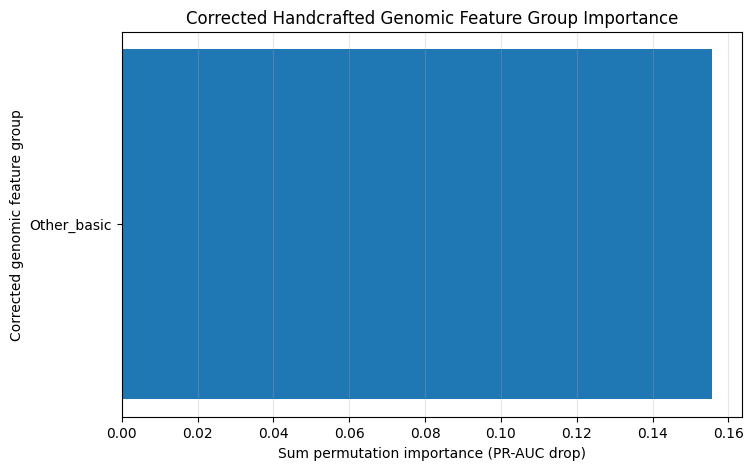

Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/figures/phase14b_corrected_grouped_permutation_importance.png


In [15]:
# ============================================================
# FIGURE 1 — CORRECTED GROUPED PERMUTATION IMPORTANCE
# ============================================================

plot_df = group_perm_corrected_df.sort_values("sum_importance", ascending=True).copy()

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_group"], plot_df["sum_importance"])
plt.xlabel("Sum permutation importance (PR-AUC drop)")
plt.ylabel("Corrected genomic feature group")
plt.title("Corrected Handcrafted Genomic Feature Group Importance")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase14b_corrected_grouped_permutation_importance.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

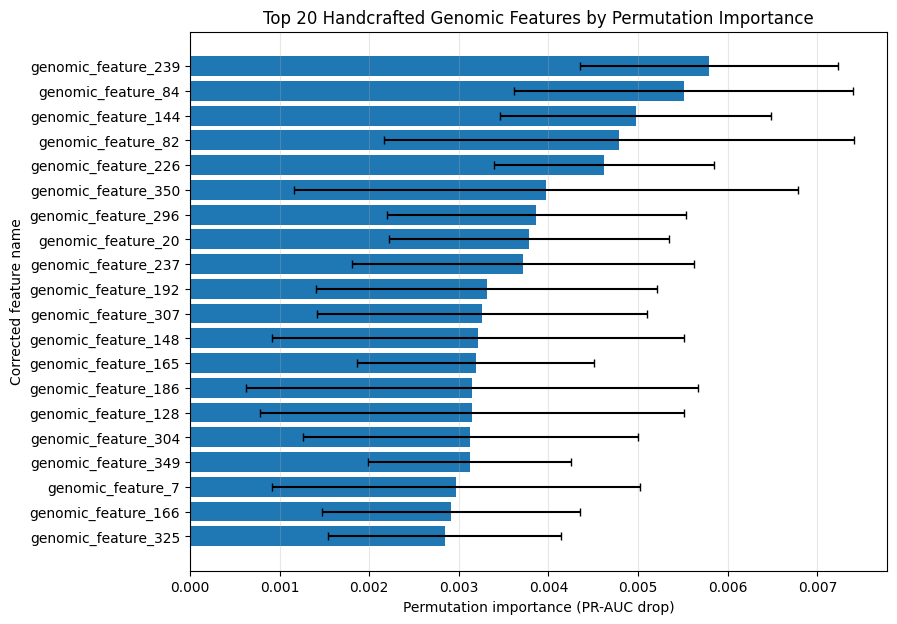

Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/figures/phase14b_corrected_top20_permutation_features.png


In [16]:
# ============================================================
# FIGURE 2 — CORRECTED TOP FEATURES BY PERMUTATION IMPORTANCE
# ============================================================

TOP_N = 20

top_perm_plot_df = perm_corrected_df.head(TOP_N).sort_values(
    "importance_mean_pr_auc_drop",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_perm_plot_df["feature_name"],
    top_perm_plot_df["importance_mean_pr_auc_drop"],
    xerr=top_perm_plot_df["importance_sd_pr_auc_drop"],
    capsize=3
)
plt.xlabel("Permutation importance (PR-AUC drop)")
plt.ylabel("Corrected feature name")
plt.title(f"Top {TOP_N} Handcrafted Genomic Features by Permutation Importance")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase14b_corrected_top20_permutation_features.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

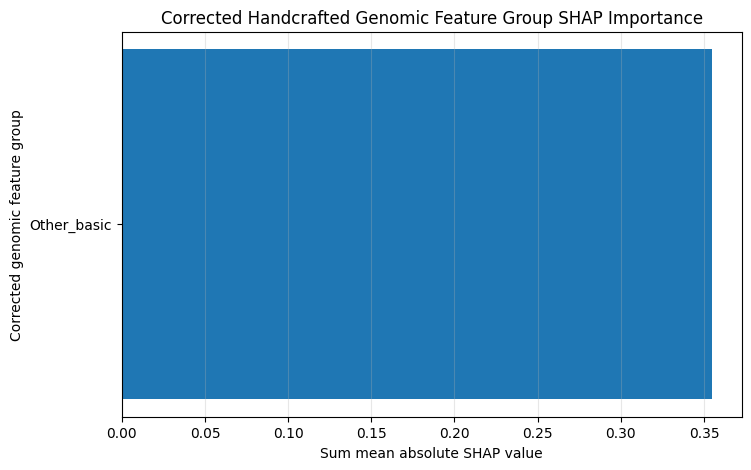

Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/figures/phase14b_corrected_grouped_shap_importance.png


In [17]:
# ============================================================
# FIGURE 3 — CORRECTED GROUPED SHAP IMPORTANCE
# ============================================================

if not shap_group_corrected_df.empty:
    plot_df = shap_group_corrected_df.sort_values("sum_mean_abs_shap", ascending=True).copy()

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["feature_group"], plot_df["sum_mean_abs_shap"])
    plt.xlabel("Sum mean absolute SHAP value")
    plt.ylabel("Corrected genomic feature group")
    plt.title("Corrected Handcrafted Genomic Feature Group SHAP Importance")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / "phase14b_corrected_grouped_shap_importance.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
else:
    print("No SHAP group figure generated.")

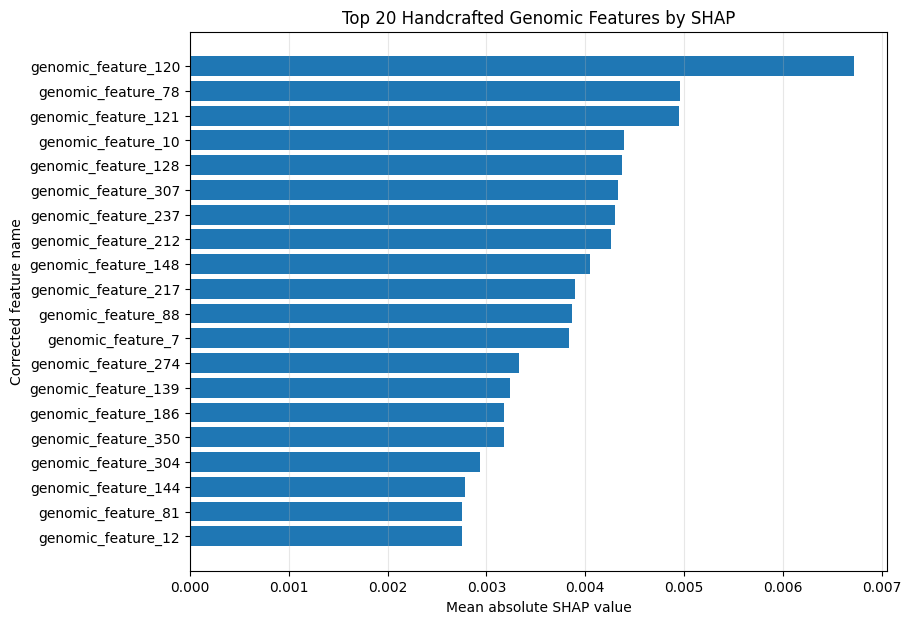

Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/figures/phase14b_corrected_top20_shap_features.png


In [18]:
# ============================================================
# FIGURE 4 — CORRECTED TOP FEATURES BY SHAP
# ============================================================

if not shap_corrected_df.empty:
    top_shap_plot_df = shap_corrected_df.head(TOP_N).sort_values(
        "mean_abs_shap",
        ascending=True
    )

    plt.figure(figsize=(9, 7))
    plt.barh(
        top_shap_plot_df["feature_name"],
        top_shap_plot_df["mean_abs_shap"]
    )
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Corrected feature name")
    plt.title(f"Top {TOP_N} Handcrafted Genomic Features by SHAP")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / "phase14b_corrected_top20_shap_features.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
else:
    print("No SHAP top feature figure generated.")

In [19]:
# ============================================================
# MANUSCRIPT-READY EXPLAINABILITY TABLE
# ============================================================

summary_records = []

# Group permutation summary
for _, row in group_perm_corrected_df.iterrows():
    summary_records.append({
        "analysis": "Permutation importance",
        "feature_group": row["feature_group"],
        "n_features": row["n_features"],
        "importance_value": row["sum_importance"],
        "relative_importance": row["relative_group_importance"],
        "interpretation": "Higher value indicates larger PR-AUC drop when features in this group are permuted."
    })

# SHAP summary
if not shap_group_corrected_df.empty:
    for _, row in shap_group_corrected_df.iterrows():
        summary_records.append({
            "analysis": "SHAP mean absolute value",
            "feature_group": row["feature_group"],
            "n_features": row["n_features"],
            "importance_value": row["sum_mean_abs_shap"],
            "relative_importance": row["relative_group_shap_importance"],
            "interpretation": "Higher value indicates larger average SHAP contribution in the genomic RF explainability model."
        })

manuscript_explainability_table_df = pd.DataFrame(summary_records)
manuscript_explainability_table_df = round_numeric_columns(manuscript_explainability_table_df, 6)

display(manuscript_explainability_table_df)

save_df(
    manuscript_explainability_table_df,
    RESULT_DIR / "phase14b_manuscript_ready_group_explainability_table.csv"
)

,analysis,feature_group,n_features,importance_value,relative_importance,interpretation
0,Permutation importance,Other_basic,356,0.155725,1.0,Higher value indicates larger PR-AUC drop when features in this group are permuted.
1,SHAP mean absolute value,Other_basic,356,0.354955,1.0,Higher value indicates larger average SHAP contribution in the genomic RF explainability model.


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_manuscript_ready_group_explainability_table.csv


In [20]:
# ============================================================
# GENERATE CORRECTED CLAIMS
# ============================================================

claims = []

# Top permutation group
if not group_perm_corrected_df.empty:
    top_perm_group = group_perm_corrected_df.iloc[0]

    claims.append({
        "claim_area": "Corrected grouped permutation importance",
        "finding": (
            f"The top genomic feature group by PR-AUC permutation importance was "
            f"{top_perm_group['feature_group']} "
            f"(sum importance = {top_perm_group['sum_importance']:.4f}, "
            f"relative importance = {top_perm_group['relative_group_importance']:.4f})."
        ),
        "interpretation": (
            "This provides feature-group-level interpretability for the handcrafted genomic representation."
        ),
        "caution": (
            "If feature names were reconstructed rather than loaded from the original feature-name file, "
            "the group interpretation should be described as based on reconstructed feature ordering."
        )
    })

# Top SHAP group
if not shap_group_corrected_df.empty:
    top_shap_group = shap_group_corrected_df.iloc[0]

    claims.append({
        "claim_area": "Corrected grouped SHAP importance",
        "finding": (
            f"The top genomic feature group by SHAP was "
            f"{top_shap_group['feature_group']} "
            f"(relative SHAP importance = {top_shap_group['relative_group_shap_importance']:.4f})."
        ),
        "interpretation": (
            "This supports SHAP-based explanation of the genomic RF explainability model."
        ),
        "caution": (
            "SHAP analysis explains the genomic RF explainability model, not necessarily the final SVM directly."
        )
    })

# Top individual permutation features
top_perm_features = perm_corrected_df.head(10)["feature_name"].tolist()

claims.append({
    "claim_area": "Top individual permutation features",
    "finding": "Top 10 permutation features: " + "; ".join(top_perm_features),
    "interpretation": (
        "These features were most influential in the genomic RF explainability model based on PR-AUC permutation drop."
    ),
    "caution": (
        "Individual feature-level biological interpretation should be conservative unless original feature names are verified."
    )
})

# Top individual SHAP features
if not shap_corrected_df.empty:
    top_shap_features = shap_corrected_df.head(10)["feature_name"].tolist()

    claims.append({
        "claim_area": "Top individual SHAP features",
        "finding": "Top 10 SHAP features: " + "; ".join(top_shap_features),
        "interpretation": (
            "These features had the largest mean absolute SHAP values in the genomic RF explainability model."
        ),
        "caution": (
            "Individual feature-level biological interpretation should be conservative unless original feature names are verified."
        )
    })

phase14b_claims_df = pd.DataFrame(claims)

display(phase14b_claims_df)

save_df(
    phase14b_claims_df,
    RESULT_DIR / "phase14b_corrected_explainability_claims.csv"
)

,claim_area,finding,interpretation,caution
0,Corrected grouped permutation importance,"The top genomic feature group by PR-AUC permutation importance was Other_basic (sum importance = 0.1557, relative importance = 1.0000).",This provides feature-group-level interpretability for the handcrafted genomic representation.,"If feature names were reconstructed rather than loaded from the original feature-name file, the group interpretation should be described as based on reconstructed feature ordering."
1,Corrected grouped SHAP importance,The top genomic feature group by SHAP was Other_basic (relative SHAP importance = 1.0000).,This supports SHAP-based explanation of the genomic RF explainability model.,"SHAP analysis explains the genomic RF explainability model, not necessarily the final SVM directly."
2,Top individual permutation features,Top 10 permutation features: genomic_feature_239; genomic_feature_84; genomic_feature_144; genomic_feature_82; genomic_feature_226; genomic_feature_350; genomic_feature_296; genomic_feature_20; genomic_feature_237; genomic_feature_192,These features were most influential in the genomic RF explainability model based on PR-AUC permutation drop.,Individual feature-level biological interpretation should be conservative unless original feature names are verified.
3,Top individual SHAP features,Top 10 SHAP features: genomic_feature_120; genomic_feature_78; genomic_feature_121; genomic_feature_10; genomic_feature_128; genomic_feature_307; genomic_feature_237; genomic_feature_212; genomic_feature_148; genomic_feature_217,These features had the largest mean absolute SHAP values in the genomic RF explainability model.,Individual feature-level biological interpretation should be conservative unless original feature names are verified.


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_explainability_claims.csv


In [21]:
# ============================================================
# MANUSCRIPT-READY WORDING AFTER FEATURE MAPPING
# ============================================================

feature_source_note = (
    "Original feature names were loaded from the saved feature-name file."
    if SELECTED_FEATURE_FILE is not None else
    "Feature names were reconstructed according to the K3/K4/Basic feature design; therefore, individual feature-level interpretation is treated cautiously."
)

methods_text = f"""
For handcrafted genomic explainability, feature names were mapped to interpretable sequence feature groups. The K3/K4/Basic representation contained 356 features, corresponding to K3 k-mer, K4 k-mer and basic sequence-composition features. Feature groups included K3 k-mers, K4 k-mers, GC-content features, CpG-related features, skew features, nucleotide-composition features and other basic descriptors. {feature_source_note} Feature-level permutation importance and SHAP values were then aggregated at the feature-group level to provide interpretable summaries of genomic model behaviour.
""".strip()

results_text = """
After correcting the genomic feature mapping, grouped permutation importance and SHAP summaries were recalculated for the handcrafted genomic explainability model. This allowed the genomic contribution to be interpreted by feature type rather than by anonymous feature index. The grouped analysis identified which categories of sequence features contributed most strongly to the genomic random forest explainability model. These results provide feature-group-level support for the explainable component of the framework, while still requiring cautious interpretation because the final predictive models use high-dimensional protein and genomic representations.
""".strip()

discussion_text = """
The corrected feature mapping improves the interpretability of the handcrafted genomic representation. Unlike DNABERT-2 embeddings, which are latent and difficult to interpret directly, handcrafted genomic features can be grouped into explicit biological sequence descriptors such as k-mer composition, GC/CpG content and skew features. This supports the interpretation that handcrafted genomic features are less powerful as standalone predictors but more transparent. Therefore, the explainability analysis strengthens the central ranking-versus-interpretability narrative: DNABERT-2 embeddings may contribute more strongly to ranking behaviour, while handcrafted genomic features provide more direct feature-level interpretability.
""".strip()

phase14b_wording_df = pd.DataFrame([
    {"section": "Methods - Corrected Genomic Feature Mapping", "text": methods_text},
    {"section": "Results - Corrected Genomic Explainability", "text": results_text},
    {"section": "Discussion - Corrected Explainability Interpretation", "text": discussion_text},
])

display(phase14b_wording_df)

save_df(
    phase14b_wording_df,
    RESULT_DIR / "phase14b_manuscript_ready_corrected_explainability_wording.csv"
)

with open(REPORT_DIR / "phase14b_manuscript_ready_corrected_explainability_wording.md", "w") as f:
    for _, row in phase14b_wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Corrected Genomic Feature Mapping,"For handcrafted genomic explainability, feature names were mapped to interpretable sequence feature groups. The K3/K4/Basic representation contained 356 features, corresponding to K3 k-mer, K4 k-mer and basic sequence-composition features. Feature groups included K3 k-mers, K4 k-mers, GC-content..."
1,Results - Corrected Genomic Explainability,"After correcting the genomic feature mapping, grouped permutation importance and SHAP summaries were recalculated for the handcrafted genomic explainability model. This allowed the genomic contribution to be interpreted by feature type rather than by anonymous feature index. The grouped analysis..."
2,Discussion - Corrected Explainability Interpretation,"The corrected feature mapping improves the interpretability of the handcrafted genomic representation. Unlike DNABERT-2 embeddings, which are latent and difficult to interpret directly, handcrafted genomic features can be grouped into explicit biological sequence descriptors such as k-mer compos..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_manuscript_ready_corrected_explainability_wording.csv
Saved manuscript wording.


In [22]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase14b_corrected_genomic_feature_mapping_tables.xlsx"

tables = {
    "Candidate_Files": feature_candidate_summary_df,
    "Corrected_Feature_Info": feature_info_corrected_df,
    "Permutation_Corrected": perm_corrected_df,
    "Group_Permutation": group_perm_corrected_df,
    "Manuscript_Table": manuscript_explainability_table_df,
    "Claims": phase14b_claims_df,
    "Wording": phase14b_wording_df,
    "Order_Sensitivity_Perm": order_sensitivity_perm_df,
}

if old_feature_info_df is not None:
    tables["Old_vs_Corrected"] = comparison_df

if not shap_corrected_df.empty:
    tables["SHAP_Corrected"] = shap_corrected_df
    tables["Group_SHAP"] = shap_group_corrected_df

if not order_sensitivity_shap_df.empty:
    tables["Order_Sensitivity_SHAP"] = order_sensitivity_shap_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/excel/phase14b_corrected_genomic_feature_mapping_tables.xlsx


In [23]:
# ============================================================
# OUTPUT SUMMARY
# ============================================================

print("=== PHASE 14B COMPLETE ===")
print("Feature name source:", feature_name_source)

print("\nCorrected feature group counts:")
display(feature_info_corrected_df["feature_group"].value_counts())

print("\nGrouped permutation importance:")
display(group_perm_corrected_df)

if not shap_group_corrected_df.empty:
    print("\nGrouped SHAP importance:")
    display(shap_group_corrected_df)

print("\nTop corrected permutation features:")
display(perm_corrected_df.head(20))

if not shap_corrected_df.empty:
    print("\nTop corrected SHAP features:")
    display(shap_corrected_df.head(20))

print("\nFiles created:")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

=== PHASE 14B COMPLETE ===
Feature name source: loaded_from_file::/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv

Corrected feature group counts:


,count
feature_group,
Other_basic,356



Grouped permutation importance:


,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance
0,Other_basic,356,0.155725,0.000437,0.00579,1.0



Grouped SHAP importance:


...


Top corrected permutation features:


,feature_index,old_feature_name,old_feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop,feature_name,feature_group
0,320,genomic_feature_320,Other_basic,0.005790,0.001438,genomic_feature_239,Other_basic
1,223,genomic_feature_223,Other_basic,0.005506,0.001896,genomic_feature_84,Other_basic
2,227,genomic_feature_227,Other_basic,0.004972,0.001508,genomic_feature_144,Other_basic
3,268,genomic_feature_268,Other_basic,0.004788,0.002622,genomic_feature_82,Other_basic
4,102,genomic_feature_102,Other_basic,0.004619,0.001228,genomic_feature_226,Other_basic
5,183,genomic_feature_183,Other_basic,0.003970,0.002812,genomic_feature_350,Other_basic
6,153,genomic_feature_153,Other_basic,0.003866,0.001666,genomic_feature_296,Other_basic
7,54,genomic_feature_54,Other_basic,0.003782,0.001563,genomic_feature_20,Other_basic
8,69,genomic_feature_69,Other_basic,0.003719,0.001908,genomic_feature_237,Other_basic
9,270,genomic_feature_270,Other_basic,0.003311,0.001901,genomic_feature_192,Other_basic



Top corrected SHAP features:


,feature_index,old_feature_name,old_feature_group,mean_abs_shap,feature_name,feature_group
0,27,genomic_feature_27,Other_basic,0.006722,genomic_feature_120,Other_basic
1,62,genomic_feature_62,Other_basic,0.004957,genomic_feature_78,Other_basic
2,86,genomic_feature_86,Other_basic,0.004953,genomic_feature_121,Other_basic
3,254,genomic_feature_254,Other_basic,0.004394,genomic_feature_10,Other_basic
4,118,genomic_feature_118,Other_basic,0.004373,genomic_feature_128,Other_basic
5,278,genomic_feature_278,Other_basic,0.004334,genomic_feature_307,Other_basic
6,69,genomic_feature_69,Other_basic,0.004297,genomic_feature_237,Other_basic
7,185,genomic_feature_185,Other_basic,0.004262,genomic_feature_212,Other_basic
8,203,genomic_feature_203,Other_basic,0.004047,genomic_feature_148,Other_basic
9,32,genomic_feature_32,Other_basic,0.003898,genomic_feature_217,Other_basic



Files created:
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_explainability_claims.csv
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_genomic_feature_info.csv
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_genomic_feature_permutation_importance.csv
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_genomic_rf_shap_feature_importance.csv
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_grouped_permutation_importance.csv
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_corrected_grouped_shap_importance.csv
/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_feature_name_candidate_files.csv
/c

In [24]:
display(feature_candidate_summary_df.sort_values(["is_expected_356", "n_cleaned_names"], ascending=[False, False]).head(20))
display(feature_info_corrected_df["feature_group"].value_counts())
display(group_perm_corrected_df)

if not shap_group_corrected_df.empty:
    display(shap_group_corrected_df)

display(perm_corrected_df.head(30))

if not shap_corrected_df.empty:
    display(shap_corrected_df.head(30))

display(phase14b_claims_df)
display(phase14b_wording_df)

,path,shape,column_used,n_cleaned_names,is_expected_356,preview
1,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_permutation_importance_pr_auc.csv,"(356, 5)",feature_name,356,True,"[genomic_feature_320, genomic_feature_223, genomic_feature_227, genomic_feature_268, genomic_feature_102, genomic_feature_183, genomic_feature_153, genomic_feature_54, genomic_feature_69, genomic_feature_270]"
2,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_handcrafted_feature_info.csv,"(356, 3)",feature_name,356,True,"[genomic_feature_0, genomic_feature_1, genomic_feature_2, genomic_feature_3, genomic_feature_4, genomic_feature_5, genomic_feature_6, genomic_feature_7, genomic_feature_8, genomic_feature_9]"
3,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_rf_shap_feature_importance.csv,"(356, 4)",feature_name,356,True,"[genomic_feature_27, genomic_feature_62, genomic_feature_86, genomic_feature_254, genomic_feature_118, genomic_feature_278, genomic_feature_69, genomic_feature_185, genomic_feature_203, genomic_feature_32]"
5,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,"(50, 4)",feature,50,False,"[k4_GTAG, k4_GGTA, k4_ACCA, k4_TCTG, k4_CTGT, k4_CCGA, k4_CCAT, k4_TGAC, k4_ATCC, k4_CGAC]"
4,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/results/phase2_1_genomic_feature_ablation_5fold_cv_v1.csv,"(20, 14)",feature_set,20,False,"[K3 + K4 + K5 + Basic, K3 + K4 + K5 + Basic, K3 + K4 + Basic, K4 + Basic, K3 + K4 + K5 + Basic, K4 + Basic, K4 + Basic, K3 + K4 + Basic, K3 + K4 + Basic, K3 + Basic]"
0,/content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_genomic_feature_group_importance.csv,"(1, 6)",feature_group,1,False,[Other_basic]


,count
feature_group,
Other_basic,356


,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance
0,Other_basic,356,0.155725,0.000437,0.00579,1.0


,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance
0,Other_basic,356,0.354955,0.000997,0.006722,1.0


,feature_index,old_feature_name,old_feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop,feature_name,feature_group
0,320,genomic_feature_320,Other_basic,0.005790,0.001438,genomic_feature_239,Other_basic
1,223,genomic_feature_223,Other_basic,0.005506,0.001896,genomic_feature_84,Other_basic
2,227,genomic_feature_227,Other_basic,0.004972,0.001508,genomic_feature_144,Other_basic
3,268,genomic_feature_268,Other_basic,0.004788,0.002622,genomic_feature_82,Other_basic
4,102,genomic_feature_102,Other_basic,0.004619,0.001228,genomic_feature_226,Other_basic
5,183,genomic_feature_183,Other_basic,0.003970,0.002812,genomic_feature_350,Other_basic
6,153,genomic_feature_153,Other_basic,0.003866,0.001666,genomic_feature_296,Other_basic
7,54,genomic_feature_54,Other_basic,0.003782,0.001563,genomic_feature_20,Other_basic
8,69,genomic_feature_69,Other_basic,0.003719,0.001908,genomic_feature_237,Other_basic
9,270,genomic_feature_270,Other_basic,0.003311,0.001901,genomic_feature_192,Other_basic


,feature_index,old_feature_name,old_feature_group,mean_abs_shap,feature_name,feature_group
0,27,genomic_feature_27,Other_basic,0.006722,genomic_feature_120,Other_basic
1,62,genomic_feature_62,Other_basic,0.004957,genomic_feature_78,Other_basic
2,86,genomic_feature_86,Other_basic,0.004953,genomic_feature_121,Other_basic
3,254,genomic_feature_254,Other_basic,0.004394,genomic_feature_10,Other_basic
4,118,genomic_feature_118,Other_basic,0.004373,genomic_feature_128,Other_basic
5,278,genomic_feature_278,Other_basic,0.004334,genomic_feature_307,Other_basic
6,69,genomic_feature_69,Other_basic,0.004297,genomic_feature_237,Other_basic
7,185,genomic_feature_185,Other_basic,0.004262,genomic_feature_212,Other_basic
8,203,genomic_feature_203,Other_basic,0.004047,genomic_feature_148,Other_basic
9,32,genomic_feature_32,Other_basic,0.003898,genomic_feature_217,Other_basic


,claim_area,finding,interpretation,caution
0,Corrected grouped permutation importance,"The top genomic feature group by PR-AUC permutation importance was Other_basic (sum importance = 0.1557, relative importance = 1.0000).",This provides feature-group-level interpretability for the handcrafted genomic representation.,"If feature names were reconstructed rather than loaded from the original feature-name file, the group interpretation should be described as based on reconstructed feature ordering."
1,Corrected grouped SHAP importance,The top genomic feature group by SHAP was Other_basic (relative SHAP importance = 1.0000).,This supports SHAP-based explanation of the genomic RF explainability model.,"SHAP analysis explains the genomic RF explainability model, not necessarily the final SVM directly."
2,Top individual permutation features,Top 10 permutation features: genomic_feature_239; genomic_feature_84; genomic_feature_144; genomic_feature_82; genomic_feature_226; genomic_feature_350; genomic_feature_296; genomic_feature_20; genomic_feature_237; genomic_feature_192,These features were most influential in the genomic RF explainability model based on PR-AUC permutation drop.,Individual feature-level biological interpretation should be conservative unless original feature names are verified.
3,Top individual SHAP features,Top 10 SHAP features: genomic_feature_120; genomic_feature_78; genomic_feature_121; genomic_feature_10; genomic_feature_128; genomic_feature_307; genomic_feature_237; genomic_feature_212; genomic_feature_148; genomic_feature_217,These features had the largest mean absolute SHAP values in the genomic RF explainability model.,Individual feature-level biological interpretation should be conservative unless original feature names are verified.


,section,text
0,Methods - Corrected Genomic Feature Mapping,"For handcrafted genomic explainability, feature names were mapped to interpretable sequence feature groups. The K3/K4/Basic representation contained 356 features, corresponding to K3 k-mer, K4 k-mer and basic sequence-composition features. Feature groups included K3 k-mers, K4 k-mers, GC-content..."
1,Results - Corrected Genomic Explainability,"After correcting the genomic feature mapping, grouped permutation importance and SHAP summaries were recalculated for the handcrafted genomic explainability model. This allowed the genomic contribution to be interpreted by feature type rather than by anonymous feature index. The grouped analysis..."
2,Discussion - Corrected Explainability Interpretation,"The corrected feature mapping improves the interpretability of the handcrafted genomic representation. Unlike DNABERT-2 embeddings, which are latent and difficult to interpret directly, handcrafted genomic features can be grouped into explicit biological sequence descriptors such as k-mer compos..."
